**Описание набора данных**

Вы анализируете базу объявлений о продаже квартир. Данные требуют предварительной очистки, после которой нужно провести исследовательский анализ и визуализировать зависимости.

Файл: `real_estate.csv`
Поля:

`id` – уникальный идентификатор объявления (целое число).

`district` – район города (строка).

`address` – адрес (строка).

`rooms` – количество комнат (целое число).

`area` – общая площадь, кв.м (число с плавающей точкой).

`floor` – этаж (целое число).

`total_floors` – этажность дома (целое число).

`price` – цена в рублях (целое число).

**Задания**

Загрузка и первичный осмотр

Загрузите данные из `real_estate.csv.`

Выведите основную информацию, описательные статистики.

Определите типы столбцов и приведите их к нужным (например, rooms – целые, но пропуск превратится в **float** – это нормально).

In [67]:
#загрузка
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = 'https://drive.google.com/uc?id=1UoK8CL5vKbtpQvfYKclkycwELUH5Ls4X&export=download'
df = pd.read_csv(url)

#первичный осмотр
print('Первые 3 строки:')
print(df.head(3))

#общая информация о датафрейм: типы данных, непропущенные значения
print('\nИнформация о dataframe:')
print(df.info())

#описательная статистика для числовых столбцов
print('\nОписательная статистика:')
print(df.describe())

#определение типов столбцов и приведение к нужным
df['id'] = pd.to_numeric (df['id'], errors = 'coerce')
df['district'] = df['district'].astype('category')
df['rooms'] = pd.to_numeric (df['rooms'], errors = 'coerce')
df['floor'] = pd.to_numeric (df['floor'], errors = 'coerce')
df['total_floors'] =pd.to_numeric (df['total_floors'], errors = 'coerce')



Первые 3 строки:
   id     district   address  rooms  area  floor  total_floors      price
0   1        Южный  ул. Z 20    NaN  75.8     16             5  8543000.0
1   2  Центральный  ул. M 10    2.0  39.3     10             9  3746000.0
2   3     Западный  ул. I 55    3.0  29.6     20             9  2850000.0

Информация о dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            101 non-null    int64  
 1   district      101 non-null    object 
 2   address       101 non-null    object 
 3   rooms         100 non-null    float64
 4   area          101 non-null    float64
 5   floor         101 non-null    int64  
 6   total_floors  101 non-null    int64  
 7   price         101 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 6.4+ KB
None

Описательная статистика:
               id       rooms      

**Очистка данных**

Удалите полные дубликаты (если есть).

Обработайте пропуски:

Для `rooms` можно заполнить медианным значением по району или всей выборке. Выберите обоснованный метод.

Исправьте логические ошибки:

Удалите строки, где этаж больше этажности дома (или замените на **NaN** и затем заполните медианой? лучше удалить такие записи, так как это критическая ошибка).

Проверьте наличие отрицательных или нулевых значений в `area`, `price`. При обнаружении удалите такие строки.

Создайте столбец `price_per_m2` (цена за квадратный метр).

In [69]:
#поиск пропущенных значений
print('Пропущенные значения до обработки:')
print(df.isnull().sum())

#выведение строк c пустыми значениями
rows_with_null = df[df.isnull().any(axis=1)]
print('\nСтроки с любыми пустыми значениями:')
print(rows_with_null)

Пропущенные значения до обработки:
id              0
district        0
address         0
rooms           1
area            0
floor           0
total_floors    0
price           0
dtype: int64

Строки с любыми пустыми значениями:
   id district   address  rooms  area  floor  total_floors      price
0   1    Южный  ул. Z 20    NaN  75.8     16             5  8543000.0


In [70]:
#обработка пропусков (rooms): видим в 0 строке с id=1 пустое значение Nan. Нам известна площадь 75 кв.м. - вероятно это 3-х комнатная квартира. можно посчитать гипотетическое количество комнат в пропорции к средним значениям rooms(2.11) и area(47.26) из описательной статистики
#Решение: заполнить пропуски интерполяцией: площадь 75 кв.м / (среднее по площади/среднее по комнатам)
df['rooms'] = df['rooms'].fillna(df['area'] / df['area'].mean() * df['rooms'].mean()).round().astype(int)

#просмотр результата заполнения rooms - должно получиться 3 комнаты:
print('Пропущенные значения после обработки:')
print('Первые 3 строки:')
print(df[df['id'] == 1])

Пропущенные значения после обработки:
Первые 3 строки:
   id district   address  rooms  area  floor  total_floors      price
0   1    Южный  ул. Z 20      3  75.8     16             5  8543000.0


In [71]:
#вывод и удаление строк, где этаж > чем этажность дома
print('\nСтроки с некорректным значением этажа:')
print((df['floor'] > df['total_floors']).sum())
print('\nОбщее количество строк:')
print(len(df))


Строки с некорректным значением этажа:
53

Общее количество строк:
101


In [72]:
#так в как более чем половине элементов исследуемой совокупности значение этажа является ложным, то пока лучше только заменить ложные значения на Null. А если в дальнейшем № этажа будет участвовать в анализе, то мы исключим нулевые значения.
df.loc[df['floor'] > df['total_floors'], 'floor'] = np.nan
print("\nПосле замены:")
print(df)
print(f"Количество NaN в столбце floor: {df['floor'].isna().sum()}")


После замены:
      id     district   address  rooms   area  floor  total_floors       price
0      1        Южный  ул. Z 20      3   75.8    NaN             5   8543000.0
1      2  Центральный  ул. M 10      2   39.3    NaN             9   3746000.0
2      3     Западный  ул. I 55      3   29.6    NaN             9   2850000.0
3      4     Северный  ул. N 31      3  -10.0    NaN             5   3039000.0
4      5        Южный  ул. M 42      3   57.5    6.0             9   6449000.0
..   ...          ...       ...    ...    ...    ...           ...         ...
96    97        Южный  ул. K 55      1   56.2   10.0            14   5247000.0
97    98        Южный  ул. B 52      2  101.0    NaN             9  10641000.0
98    99        Южный  ул. T 27      4   41.0    NaN             9   4555000.0
99   100     Западный  ул. B 56      1   30.8    4.0             9   3276000.0
100    2  Центральный  ул. M 10      2   39.3    NaN             9   3746000.0

[101 rows x 8 columns]
Количество Na

In [78]:
#видим в таблице отрицательные значения в area, также проверяем price
print(f"Количество area <=0: {(df['area'] <= 0).sum()}")
print(f"Количество price <=0: {(df['price'] <= 0).sum()}")

count = ((df['price'] <= 0).sum() | (df['area'] <= 0).sum())
print(f"Итого количество строк для очистки: {count}")


Количество area <=0: 1
Количество price <=0: 0
Итого количество строк для очистки: 1


In [80]:
#очищаем area = выводим строки только с нужным результатом > 0
df = df[df['area'] > 0]
print(f"Количество area <=0 после очистки: {(df['area'] <= 0).sum()}")

#очищаем price = выводим строки только с нужным результатом > 0
df = df[df['price'] > 0]
print(f"Количество price <=0 после очистки: {(df['price'] <= 0).sum()}")

#выводим количество строк после очистки (должно быть 101 -1 = 100)
print(f'\nИтого количество строк после очистки: {len(df)}')


Количество area <=0 после очистки: 0
Количество price <=0 после очистки: 0

Итого количество строк после очистки: 100


In [86]:
#создаем столбец price_per_m2 (цена за квадратный метр)
df['price_per_m2'] = (df['price'] / df['area']).round(2).astype(float)

#просматриваем результат на основании первых 10 значений
print(df.head(10))

    id     district   address  rooms  area  floor  total_floors      price  \
0    1        Южный  ул. Z 20      3  75.8    NaN             5  8543000.0   
1    2  Центральный  ул. M 10      2  39.3    NaN             9  3746000.0   
2    3     Западный  ул. I 55      3  29.6    NaN             9  2850000.0   
4    5        Южный  ул. M 42      3  57.5    6.0             9  6449000.0   
5    6        Южный  ул. S 26      5  56.2    NaN             9  5820000.0   
6    7     Западный  ул. S 45      2  52.4    NaN            14  6048000.0   
7    8     Северный  ул. N 28      2  76.5    NaN             5  7666000.0   
8    9     Северный  ул. U 92      3  35.9    6.0            17  3521000.0   
9   10     Западный  ул. R 45      1  23.6    NaN             9  2651000.0   
10  11    Восточный  ул. M 96      1  44.5    NaN             5  4500000.0   

    price_per_m2  
0      112704.49  
1       95318.07  
2       96283.78  
4      112156.52  
5      103558.72  
6      115419.85  
7      1

**Фильтрация данных и срезы**

Отберите квартиры с количеством комнат 1, 2, 3.

Из этого набора выберите квартиры в Центральном районе площадью не менее **40** кв.м.

Используя векторные операции, найдите самую дешёвую квартиру в каждом районе (среди 1-3 комнатных).

In [100]:
#выводим статистику по количеству элементов по типам комнат
print("Статистика по комнатам:")
print(df['rooms'].value_counts().sort_index())
#видим, чо большинство значений попадает в интервал <= 3 комнаты

Статистика по комнатам:
rooms
1    30
2    44
3    17
4     3
5     6
Name: count, dtype: int64


In [117]:
#фильтруем данные чтобы оставить значения только с количеством комнат до 3
df_original_rooms = df[df['rooms'] <= 3]

#выводим данные
print(f"Найдено квартир с количеством комнат до 3х: {len(df_original_rooms)}")
print(df_original_rooms)

Найдено квартир с количеством комнат до 3х: 91
      id     district   address  rooms   area  floor  total_floors  \
0      1        Южный  ул. Z 20      3   75.8    NaN             5   
1      2  Центральный  ул. M 10      2   39.3    NaN             9   
2      3     Западный  ул. I 55      3   29.6    NaN             9   
4      5        Южный  ул. M 42      3   57.5    6.0             9   
6      7     Западный  ул. S 45      2   52.4    NaN            14   
..   ...          ...       ...    ...    ...    ...           ...   
95    96     Северный  ул. B 45      1   65.0    2.0             5   
96    97        Южный  ул. K 55      1   56.2   10.0            14   
97    98        Южный  ул. B 52      2  101.0    NaN             9   
99   100     Западный  ул. B 56      1   30.8    4.0             9   
100    2  Центральный  ул. M 10      2   39.3    NaN             9   

          price  price_per_m2  
0     8543000.0     112704.49  
1     3746000.0      95318.07  
2     2850000.0 

In [118]:
#выводим статистику по районам
print("Статистика по районам:")
print(df['district'].value_counts().sort_index())

Статистика по районам:
district
Восточный      17
Западный       22
Северный       14
Центральный    21
Южный          26
Name: count, dtype: int64


In [119]:
#фильтруем данные, чтобы сделать срез по Центральному району и площади >= 40 кв.м.
df_result = df[(df['rooms'].isin([1, 2, 3])) & (df['district'] == 'Центральный') & (df['area'] >= 40)]

#выводим данные
print(f"Найдено квартир: {len(df_result)}")
print(df_result)

Найдено квартир: 11
    id     district   address  rooms  area  floor  total_floors       price  \
13  14  Центральный  ул. Y 67      2  63.0    7.0             9   5276000.0   
16  17  Центральный  ул. E 17      2  44.4    3.0             9   4323000.0   
18  19  Центральный  ул. I 82      3  64.8    NaN             5   5775000.0   
28  29  Центральный  ул. Y 72      3  61.0    NaN             9   6161000.0   
29  30  Центральный  ул. W 75      2  41.2    NaN             5   4425000.0   
37  38  Центральный  ул. M 48      1  60.4    4.0             9   4939000.0   
39  40  Центральный  ул. C 48      2  66.5    NaN             9   5457000.0   
43  44  Центральный  ул. V 12      1  53.1    NaN             5   6335000.0   
56  57  Центральный  ул. O 43      2  90.1    7.0             9  10383000.0   
65  66  Центральный  ул. N 40      2  48.9    NaN             5   4530000.0   
79  80  Центральный  ул. R 93      1  68.9    4.0            14   7180000.0   

    price_per_m2  
13      8374

In [132]:
#Используя векторные операции, находим самую дешёвую квартиру в каждом районе (среди 1-3 комнатных)
#фильтруем
df_filtered = df[df['rooms'] <= 3]
#группируем с выводом минимального значения
min_price_by_district = df.groupby('district', observed=True)['price'].min()
#выводим данные
print(min_price_by_district)

district
Восточный      1632000.0
Западный       2651000.0
Северный       1686000.0
Центральный    1668000.0
Южный          1741000.0
Name: price, dtype: float64


**Группировка и агрегация**

Сгруппируйте данные по районам и посчитайте среднюю цену, минимальную/максимальную цену, среднюю площадь и количество объявлений в каждом районе.

Сохраните результат агрегации в отдельный CSV-файл `districts_stats.csv`.

In [160]:
#группируем и вычисляем
df['district'] = df['district'].astype(str)
stats = df.groupby('district').agg(
    средняя_цена=('price', 'mean'),
    мин_цена=('price', 'min'),
    макс_цена=('price', 'max'),
    средняя_площадь=('area', 'mean'),
    количество=('price', 'count')
).round(0).astype(int)
#выводим результат
print(stats)

             средняя_цена  мин_цена  макс_цена  средняя_площадь  количество
district                                                                   
Восточный         4071412   1632000    8130000               41          17
Западный          4905045   2651000    7572000               46          22
Северный          5199000   1686000    9013000               50          14
Центральный       4535762   1668000   10383000               47          21
Южный             5382038   1741000   10641000               53          26


In [161]:
#Сохраняем результат агрегации в отдельный CSV-файл districts_stats.csv.
stats.to_csv('districts_stats.csv')
print("Файл 'districts_stats.csv' успешно сохранён!")

Файл 'districts_stats.csv' успешно сохранён!


In [163]:
#проверяем содержимое сохраненного файла
df_check = pd.read_csv('districts_stats.csv')
print("Содержимое сохранённого файла:")
print(df_check)

Содержимое сохранённого файла:
      district  средняя_цена  мин_цена  макс_цена  средняя_площадь  количество
0    Восточный       4071412   1632000    8130000               41          17
1     Западный       4905045   2651000    7572000               46          22
2     Северный       5199000   1686000    9013000               50          14
3  Центральный       4535762   1668000   10383000               47          21
4        Южный       5382038   1741000   10641000               53          26


**Визуализация с seaborn**

Постройте гистограмму распределения цен на квартиры.

Постройте boxplot распределения цен в зависимости от количества комнат.

Постройте scatter plot зависимости цены от площади, окрасив точки по районам.

Добавьте заголовки, подписи осей, легенду.

Сделайте выводы о возможных зависимостях (в текстовом формате).

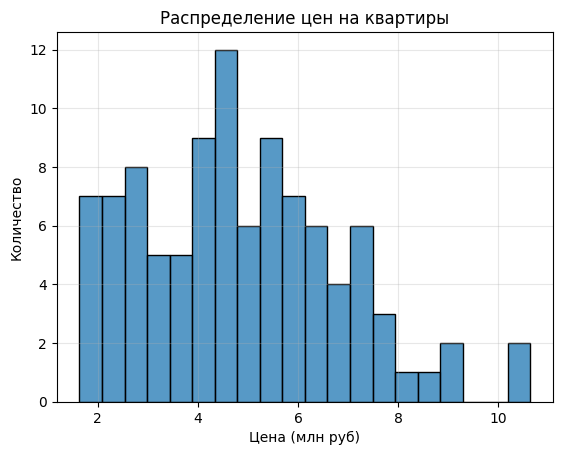


Самое большое количество исследуемых квартир (12) продаются по цене 4,3 млн руб. Самое маленькое количество квартир (до 2) продаются по ценам от 8 до 11 млн.руб. 
Следовательно, чем выше цена квартиры, тем в меньшей степени такие квартиры встречаются в датасете. Корелляция между ценой и количеством исследуемых квартир отрицательная.


In [245]:
#гистограмма распределения цен на квартиры
sns.histplot(x = df['price'] / 1000000, bins=20, edgecolor='black')
#добавление заголовков, подписей осей, легенды
plt.xlabel('Цена (млн руб)')
plt.ylabel('Количество')
plt.title('Распределение цен на квартиры')
plt.grid(True, alpha=0.3)
plt.show()
#выводы о возможных зависимостях (в текстовом формате)
print(f"\nСамое большое количество исследуемых квартир (12) продаются по цене 4,3 млн руб. Самое маленькое количество квартир (до 2) продаются по ценам от 8 до 11 млн.руб. \nСледовательно, чем выше цена квартиры, тем в меньшей степени такие квартиры встречаются в датасете. Корелляция между ценой и количеством исследуемых квартир отрицательная.")


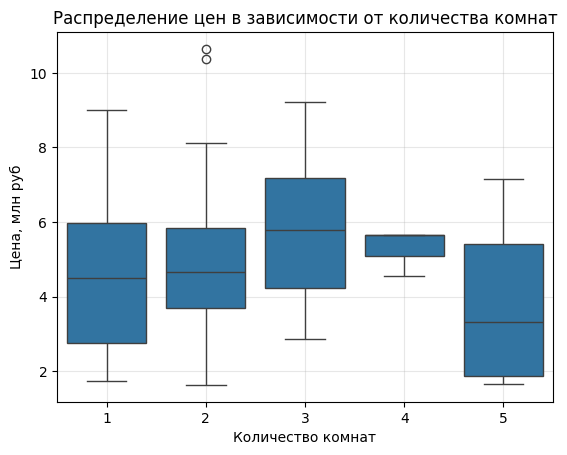


Наблюдается неравномерное распределение: с увеличением количества комнат цена 5-конатных квартир не возрастает. 
У однокомнатных квартир наблюдаются самые большие выбросы по цене. 
Вывод: Рекомендуется еще раз произвести анализ атрибута price и очистку данных от возможных выбросов/искажений/опечаток.


In [238]:
#boxplot распределения цен в зависимости от количества комнат
sns.boxplot(x='rooms', y=df['price'] / 1000000, data=df)
#добавление заголовков, подписей осей, легенды
plt.xlabel('Количество комнат')
plt.ylabel('Цена, млн руб')
plt.title('Распределение цен в зависимости от количества комнат')
plt.grid(True, alpha=0.3)
plt.show()
#выводы о возможных зависимостях (в текстовом формате)

print(f"\nНаблюдается неравномерное распределение: с увеличением количества комнат цена 5-конатных квартир не возрастает. \nУ однокомнатных квартир наблюдаются самые большие выбросы по цене. \nВывод: Рекомендуется еще раз произвести анализ атрибута price и очистку данных от возможных выбросов/искажений/опечаток.")



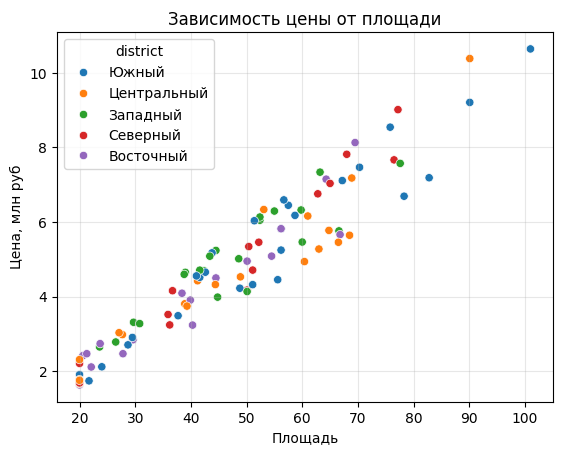


Самое большое количество исследуемых квартир (точек) наблюдаются в диапазоне площади квартиры от 35 до 70 кв.м. 
Самые низкие цены - у маленьких по площади квартир (до 35 кв.м.). Самые высокие цены - у больших по площади квартир (от 70 кв.м). 
Следовательно, чем больше площадь квартиры, тем выше ее цена. Корелляция между ценой и площадью квартиры положительная. 


In [243]:
#scatter plot зависимости цены от площади, окраска точек по районам
sns.scatterplot(data=df, x='area', y=df['price'] / 1000000, hue='district')
#добавление заголовков, подписей осей, легенды
plt.xlabel('Площадь')
plt.ylabel('Цена, млн руб')
plt.title('Зависимость цены от площади')
plt.grid(True, alpha=0.3)
plt.show()
#выводы о возможных зависимостях (в текстовом формате)
print(f"\nСамое большое количество исследуемых квартир (точек) наблюдаются в диапазоне площади квартиры от 35 до 70 кв.м. \nСамые низкие цены - у маленьких по площади квартир (до 35 кв.м.). Самые высокие цены - у больших по площади квартир (от 70 кв.м). \nСледовательно, чем больше площадь квартиры, тем выше ее цена. Корелляция между ценой и площадью квартиры положительная. ")
